In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("./data_airline_reviews_1.xlsx")


In [3]:
df.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          20000 non-null  object 
 1   overall          19680 non-null  float64
 2   author           20000 non-null  object 
 3   review_date      20000 non-null  object 
 4   customer_review  20000 non-null  object 
 5   aircraft         6283 non-null   object 
 6   traveller_type   13311 non-null  object 
 7   cabin            19289 non-null  object 
 8   route            13301 non-null  object 
 9   date_flown       13280 non-null  object 
 10  seat_comfort     18857 non-null  float64
 11  cabin_service    18876 non-null  float64
 12  food_bev         16916 non-null  float64
 13  entertainment    14733 non-null  float64
 14  ground_service   13214 non-null  float64
 15  value_for_money  19429 non-null  float64
 16  recommended      19497 non-null  object 
dtypes: float64(7

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
overall,19680.0,4.988211,3.512952,1.0,1.0,5.0,9.0,10.0
seat_comfort,18857.0,2.976826,1.436701,1.0,2.0,3.0,4.0,5.0
cabin_service,18876.0,3.167355,1.569719,1.0,2.0,3.0,5.0,5.0
food_bev,16916.0,2.971743,1.483867,1.0,1.0,3.0,4.0,5.0
entertainment,14733.0,3.061562,1.522952,1.0,1.0,3.0,4.0,5.0
ground_service,13214.0,2.630922,1.611870,1.0,1.0,2.0,4.0,5.0
value_for_money,19429.0,2.883216,1.582083,1.0,1.0,3.0,4.0,5.0


In [6]:
df.duplicated().sum()

20189

In [7]:
df=df.drop_duplicates()

In [8]:
df.shape

(19811, 17)

In [9]:
df.isnull().sum()

airline                1
overall              315
author                 1
review_date            1
customer_review        1
aircraft           13528
traveller_type      6501
cabin                707
route               6511
date_flown          6532
seat_comfort        1141
cabin_service       1123
food_bev            3080
entertainment       5256
ground_service      6598
value_for_money      569
recommended          502
dtype: int64

In [10]:
df.isnull().sum()/df.shape[0]*100

airline             0.005048
overall             1.590026
author              0.005048
review_date         0.005048
customer_review     0.005048
aircraft           68.285296
traveller_type     32.815103
cabin               3.568724
route              32.865580
date_flown         32.971581
seat_comfort        5.759427
cabin_service       5.668568
food_bev           15.546918
entertainment      26.530715
ground_service     33.304730
value_for_money     2.872142
recommended         2.533946
dtype: float64

In [11]:
def drop_null(df):
    null_percentage=df.isnull().sum()/df.shape[0]*100
    columns_to_drop=[col for col in df.columns if null_percentage[col]>25.00]
    df.drop(columns=columns_to_drop, inplace=True)
    return df

In [12]:
drop_null(df)

,airline,overall,author,review_date,customer_review,cabin,seat_comfort,cabin_service,food_bev,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,Economy Class,4.0,5.0,4.0,4.0,yes
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,Economy Class,4.0,1.0,1.0,1.0,no
5,Turkish Airlines,3.0,M Galerko,7th May 2019,âœ… Trip Verified | Rome to Prishtina via Ista...,Economy Class,1.0,4.0,1.0,2.0,no
7,Turkish Airlines,10.0,Zeshan Shah,6th May 2019,âœ… Trip Verified | Flew on Turkish Airlines I...,Economy Class,4.0,5.0,5.0,5.0,yes
...,...,...,...,...,...,...,...,...,...,...,...
39991,Alitalia,7.0,T Matava,6th July 2014,AZ703 IST-FCO connecting onto AZ 630 FCO-MIA B...,NaN,NaN,NaN,NaN,NaN,NaN
39993,Alitalia,10.0,S Kesavan,30th June 2014,Flew from Rome to Lamezia Terme and back. A mo...,Economy Class,4.0,5.0,5.0,5.0,yes
39995,Alitalia,9.0,D Cerulli,30th June 2014,Rome to Nice and return. We took off 10 mins e...,Economy Class,4.0,5.0,3.0,5.0,yes
39997,Alitalia,NaN,N Yanaky,25th June 2014,My parents and I were returning from a lovely ...,Economy Class,1.0,3.0,1.0,3.0,no


In [13]:
df.isnull().sum()/df.shape[0]*100

airline             0.005048
overall             1.590026
author              0.005048
review_date         0.005048
customer_review     0.005048
cabin               3.568724
seat_comfort        5.759427
cabin_service       5.668568
food_bev           15.546918
value_for_money     2.872142
recommended         2.533946
dtype: float64

In [14]:
df.dropna(axis=1,how="all",inplace=True)

In [15]:
df.dropna(axis=0,how="all",inplace=True)

In [16]:
df.shape

(19810, 11)

In [17]:
list(df.columns)

['airline',
 'overall',
 'author',
 'review_date',
 'customer_review',
 'cabin',
 'seat_comfort',
 'cabin_service',
 'food_bev',
 'value_for_money',
 'recommended']

In [18]:
df.dtypes

airline             object
overall            float64
author              object
review_date         object
customer_review     object
cabin               object
seat_comfort       float64
cabin_service      float64
food_bev           float64
value_for_money    float64
recommended         object
dtype: object

In [19]:
df.head(4)

,airline,overall,author,review_date,customer_review,cabin,seat_comfort,cabin_service,food_bev,value_for_money,recommended
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,Economy Class,4.0,5.0,4.0,4.0,yes
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,Economy Class,4.0,1.0,1.0,1.0,no
5,Turkish Airlines,3.0,M Galerko,7th May 2019,âœ… Trip Verified | Rome to Prishtina via Ista...,Economy Class,1.0,4.0,1.0,2.0,no
7,Turkish Airlines,10.0,Zeshan Shah,6th May 2019,âœ… Trip Verified | Flew on Turkish Airlines I...,Economy Class,4.0,5.0,5.0,5.0,yes


In [20]:
df['review_date']=pd.to_datetime(df['review_date'],errors='coerce')

In [21]:
df.dtypes

airline                    object
overall                   float64
author                     object
review_date        datetime64[ns]
customer_review            object
cabin                      object
seat_comfort              float64
cabin_service             float64
food_bev                  float64
value_for_money           float64
recommended                object
dtype: object

In [22]:
df['author'].value_counts()

Anders Pedersen      49
T Eldem              45
R Sanyal             32
Tercon Bojan         24
Peter Pomeranze      23
                     ..
D Harding             1
J Buuck               1
Con Murphy            1
Graham Fairclough     1
Giovanni Rossi        1
Name: author, Length: 16038, dtype: int64

In [23]:
!pip install textblob -i https://pypi.python.org/simple


Looking in indexes: https://pypi.python.org/simple


In [24]:
from textblob import TextBlob
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity
df['sentiment_score']=df['customer_review'].apply(get_sentiment)
print("sentiment analysis applied.sentiment score added to dataset.")

sentiment analysis applied.sentiment score added to dataset.


In [25]:
df.head()

,airline,overall,author,review_date,customer_review,cabin,seat_comfort,cabin_service,food_bev,value_for_money,recommended,sentiment_score
1,Turkish Airlines,7.0,Christopher Hackley,2019-05-08,âœ… Trip Verified | London to Izmir via Istanb...,Economy Class,4.0,5.0,4.0,4.0,yes,0.260263
3,Turkish Airlines,2.0,Adriana Pisoi,2019-05-07,âœ… Trip Verified | Istanbul to Bucharest. We ...,Economy Class,4.0,1.0,1.0,1.0,no,0.116667
5,Turkish Airlines,3.0,M Galerko,2019-05-07,âœ… Trip Verified | Rome to Prishtina via Ista...,Economy Class,1.0,4.0,1.0,2.0,no,0.019803
7,Turkish Airlines,10.0,Zeshan Shah,2019-05-06,âœ… Trip Verified | Flew on Turkish Airlines I...,Economy Class,4.0,5.0,5.0,5.0,yes,0.345238
9,Turkish Airlines,1.0,Pooja Jain,2019-05-06,âœ… Trip Verified | Mumbai to Dublin via Istan...,Economy Class,1.0,1.0,1.0,1.0,no,0.191667


In [26]:
df.drop(columns=['customer_review'],inplace=True)

In [27]:
df.drop(columns=['author','review_date'],inplace=True)

In [28]:
df['airline'].value_counts

<bound method IndexOpsMixin.value_counts of 1        Turkish Airlines
3        Turkish Airlines
5        Turkish Airlines
7        Turkish Airlines
9        Turkish Airlines
               ...       
39991            Alitalia
39993            Alitalia
39995            Alitalia
39997            Alitalia
39999            Alitalia
Name: airline, Length: 19810, dtype: object>

In [29]:
df['cabin'].value_counts()

Economy Class      14352
Business Class      3141
Premium Economy      853
First Class          758
Name: cabin, dtype: int64

In [30]:
df.isnull().sum()

airline               0
overall             314
cabin               706
seat_comfort       1140
cabin_service      1122
food_bev           3079
value_for_money     568
recommended         501
sentiment_score       0
dtype: int64

In [31]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,19810,17,American Airlines,2846,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall,19496.0,NaN,NaN,NaN,4.986561,3.513638,1.0,1.0,5.0,9.0,10.0
cabin,19104,4,Economy Class,14352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seat_comfort,18670.0,NaN,NaN,NaN,2.975201,1.437272,1.0,2.0,3.0,4.0,5.0
cabin_service,18688.0,NaN,NaN,NaN,3.166738,1.569674,1.0,2.0,3.0,5.0,5.0
food_bev,16731.0,NaN,NaN,NaN,2.972088,1.484246,1.0,1.0,3.0,4.0,5.0
value_for_money,19242.0,NaN,NaN,NaN,2.881561,1.58348,1.0,1.0,3.0,4.0,5.0
recommended,19309,2,no,10470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_score,19810.0,NaN,NaN,NaN,0.110325,0.207027,-1.0,-0.020186,0.1,0.243927,1.0


In [32]:
df['overall'].fillna(df['overall'].mean(),inplace=True)
df['cabin'].fillna(df['cabin'].mode()[0],inplace=True)
df['seat_comfort'].fillna(df['seat_comfort'].mean(),inplace=True)
df['cabin_service'].fillna(df['cabin_service'].mean(),inplace=True)
df['food_bev'].fillna(df['food_bev'].mean(),inplace=True)
df['value_for_money'].fillna(df['value_for_money'].mean(),inplace=True)
df['recommended'].fillna(df['recommended'].mode()[0],inplace=True)


In [33]:
df.head(4)

,airline,overall,cabin,seat_comfort,cabin_service,food_bev,value_for_money,recommended,sentiment_score
1,Turkish Airlines,7.0,Economy Class,4.0,5.0,4.0,4.0,yes,0.260263
3,Turkish Airlines,2.0,Economy Class,4.0,1.0,1.0,1.0,no,0.116667
5,Turkish Airlines,3.0,Economy Class,1.0,4.0,1.0,2.0,no,0.019803
7,Turkish Airlines,10.0,Economy Class,4.0,5.0,5.0,5.0,yes,0.345238


In [34]:
df.isnull().sum()

airline            0
overall            0
cabin              0
seat_comfort       0
cabin_service      0
food_bev           0
value_for_money    0
recommended        0
sentiment_score    0
dtype: int64

In [35]:
#EXPLORING DATA

In [36]:
#define numerical & categorical columns

In [37]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']
print('we have{} numerical features:{}'.format(len(numeric_features),numeric_features))
print('\n we have{} categorical features:{}'.format(len(categorical_features),categorical_features))

we have6 numerical features:['overall', 'seat_comfort', 'cabin_service', 'food_bev', 'value_for_money', 'sentiment_score']

 we have3 categorical features:['airline', 'cabin', 'recommended']


In [38]:
for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('--------------------------')

American Airlines            14.366482
United Airlines              14.003029
Emirates                      8.899546
Delta Air Lines               7.748612
Turkish Airlines              7.460878
Qatar Airways                 7.218576
Lufthansa                     7.072186
Air Canada                    6.420999
KLM Royal Dutch Airlines      4.891469
Southwest Airlines            4.588592
Jetblue Airways               3.240787
Air New Zealand               3.069157
Aegean Airlines               2.675416
Aeroflot Russian Airlines     2.529026
Aeromexico                    2.205957
Alitalia                      2.044422
Virgin America                1.564866
Name: airline, dtype: float64
--------------------------
Economy Class      76.012115
Business Class     15.855628
Premium Economy     4.305906
First Class         3.826350
Name: cabin, dtype: float64
--------------------------
no     55.381121
yes    44.618879
Name: recommended, dtype: float64
--------------------------


In [39]:
#univariate Analysis  uni means one

Numerical features

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


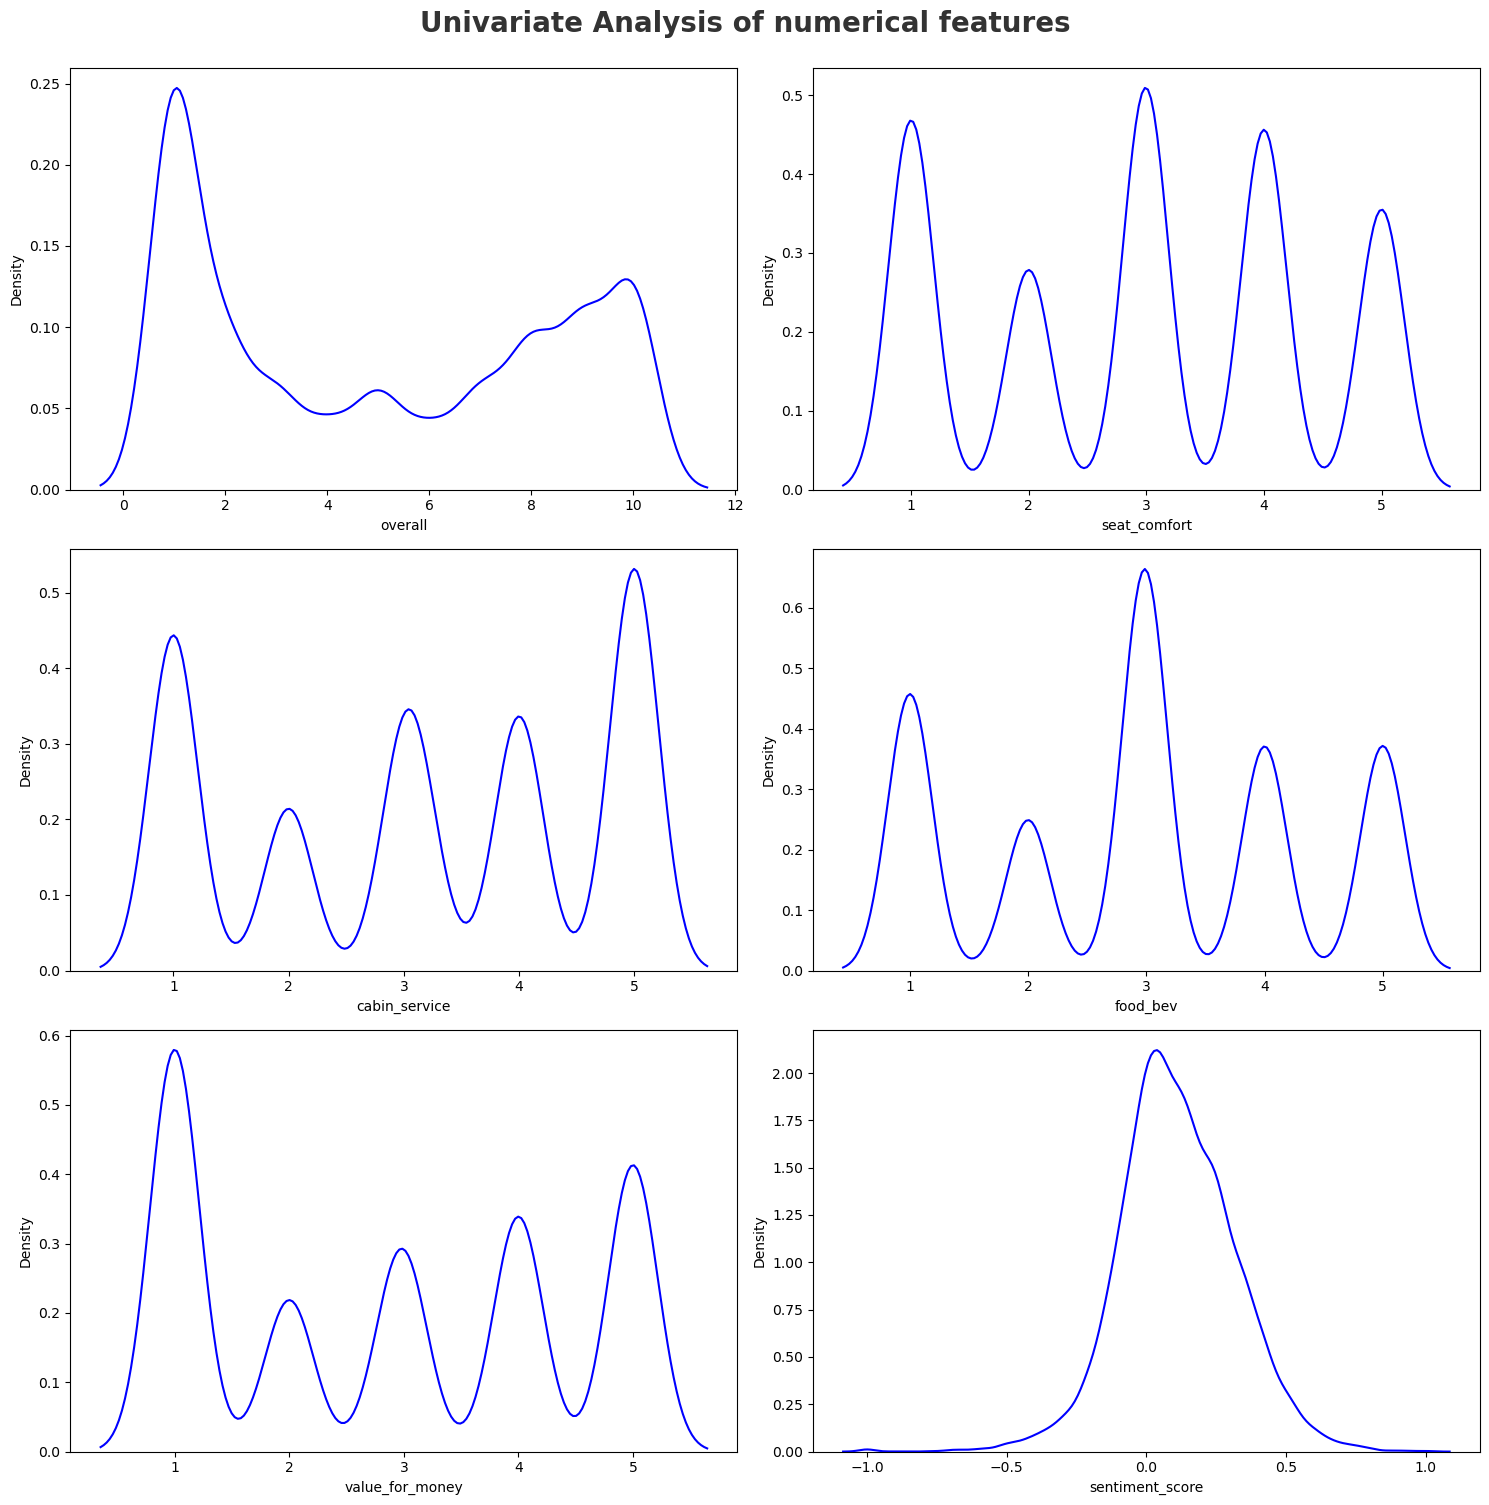

In [41]:
n_features=len(numeric_features)
n_cols=2
n_rows=int(np.ceil(n_features/n_cols))
plt.figure(figsize=(15,5*n_rows))
plt.suptitle('Univariate Analysis of numerical features',fontsize=20,fontweight='bold',alpha=0.8,y=1.)
for i in range(n_features):
    plt.subplot(n_rows,n_cols,i+1)
    sns.kdeplot(x=df[numeric_features[i]],color='blue')
    plt.xlabel(numeric_features[i])
plt.tight_layout()
plt.show()

categorical features

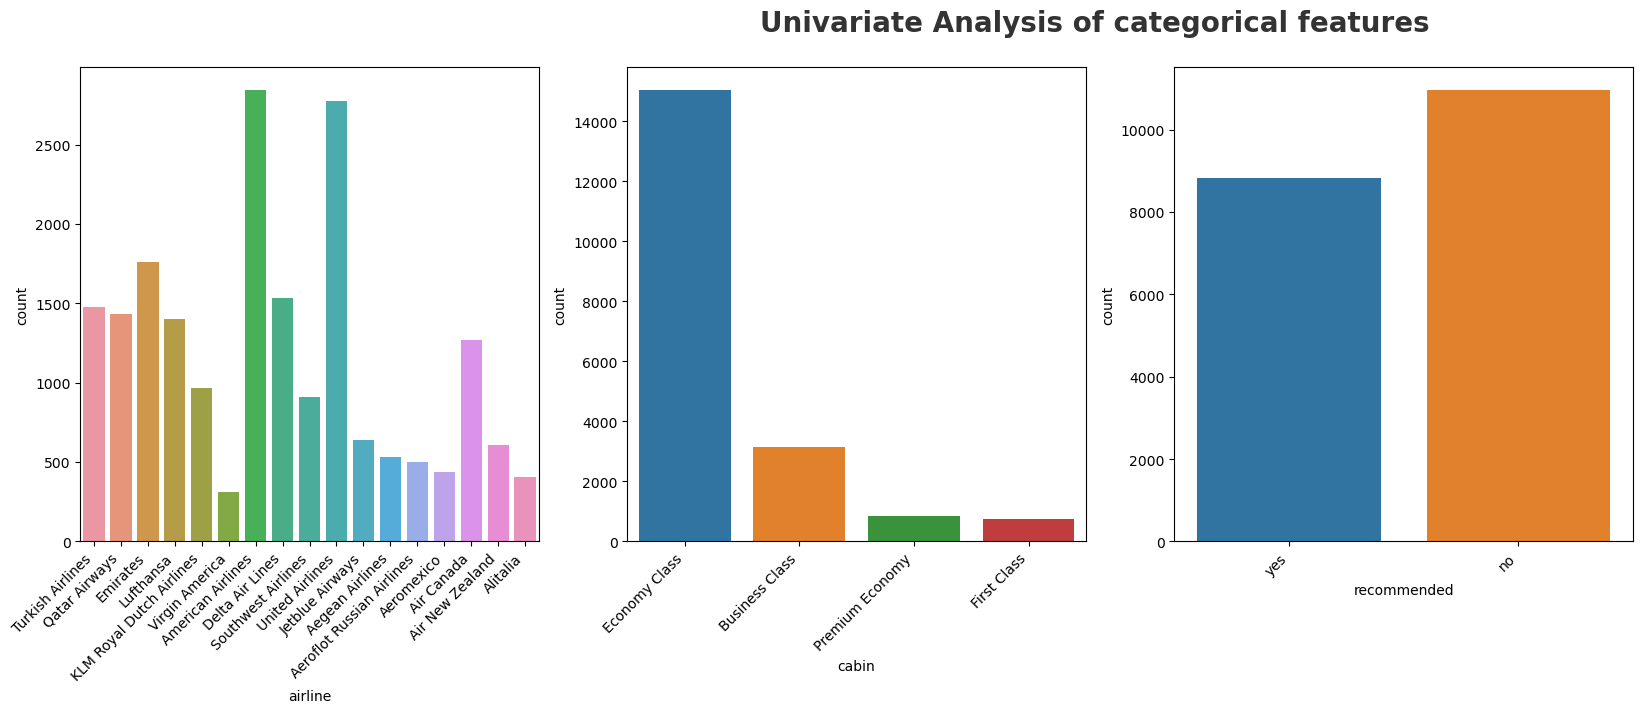

In [42]:
plt.figure(figsize=(22,25))
plt.suptitle('Univariate Analysis of categorical features',fontsize=20,fontweight='bold',alpha=.8,y=1.)
for i in range(0,len(categorical_features)):
    plt.subplot(4,4,i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.xticks(rotation=45,ha='right')
    plt.tight_layout()

In [43]:
#categorical features consists of 2 types
#1.discrete
#2.continuos


In [44]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]
continous_features=[feature for feature in numeric_features if len(df[feature].unique())>25]
print("we have{} discrete features:{}".format(len(discrete_features),discrete_features))
print("we have {} continous features:{}".format(len(continous_features),continous_features))

we have5 discrete features:['overall', 'seat_comfort', 'cabin_service', 'food_bev', 'value_for_money']
we have 1 continous features:['sentiment_score']


# check multicoolinearty for categorical features

In [45]:
from scipy.stats import chi2_contingency
chi2_test=[]
for feature in categorical_features:
    if(chi2_contingency(pd.crosstab(df['recommended'],df[feature]))[1]<0.05):
       chi2_test.append('Reject Null Hyothesis')
    else:
       chi2_test.append('fail to reject Null hypothesis')
result=pd.DataFrame(data=[categorical_features,chi2_test]).T
result.columns={'Column','Hypothesis Result'}
result

,Hypothesis Result,Column
0,airline,Reject Null Hyothesis
1,cabin,Reject Null Hyothesis
2,recommended,Reject Null Hyothesis


In [46]:
from scipy.stats import chi2_contingency
chi2_test=[]
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['recommended'],df[feature]))[1]<0.05:
        chi2_test.append('reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result=pd.DataFrame(data=[categorical_features,chi2_test]).T
result.columns=['Column','Hypothesis Result']
result

,Column,Hypothesis Result
0,airline,reject Null Hypothesis
1,cabin,reject Null Hypothesis
2,recommended,reject Null Hypothesis


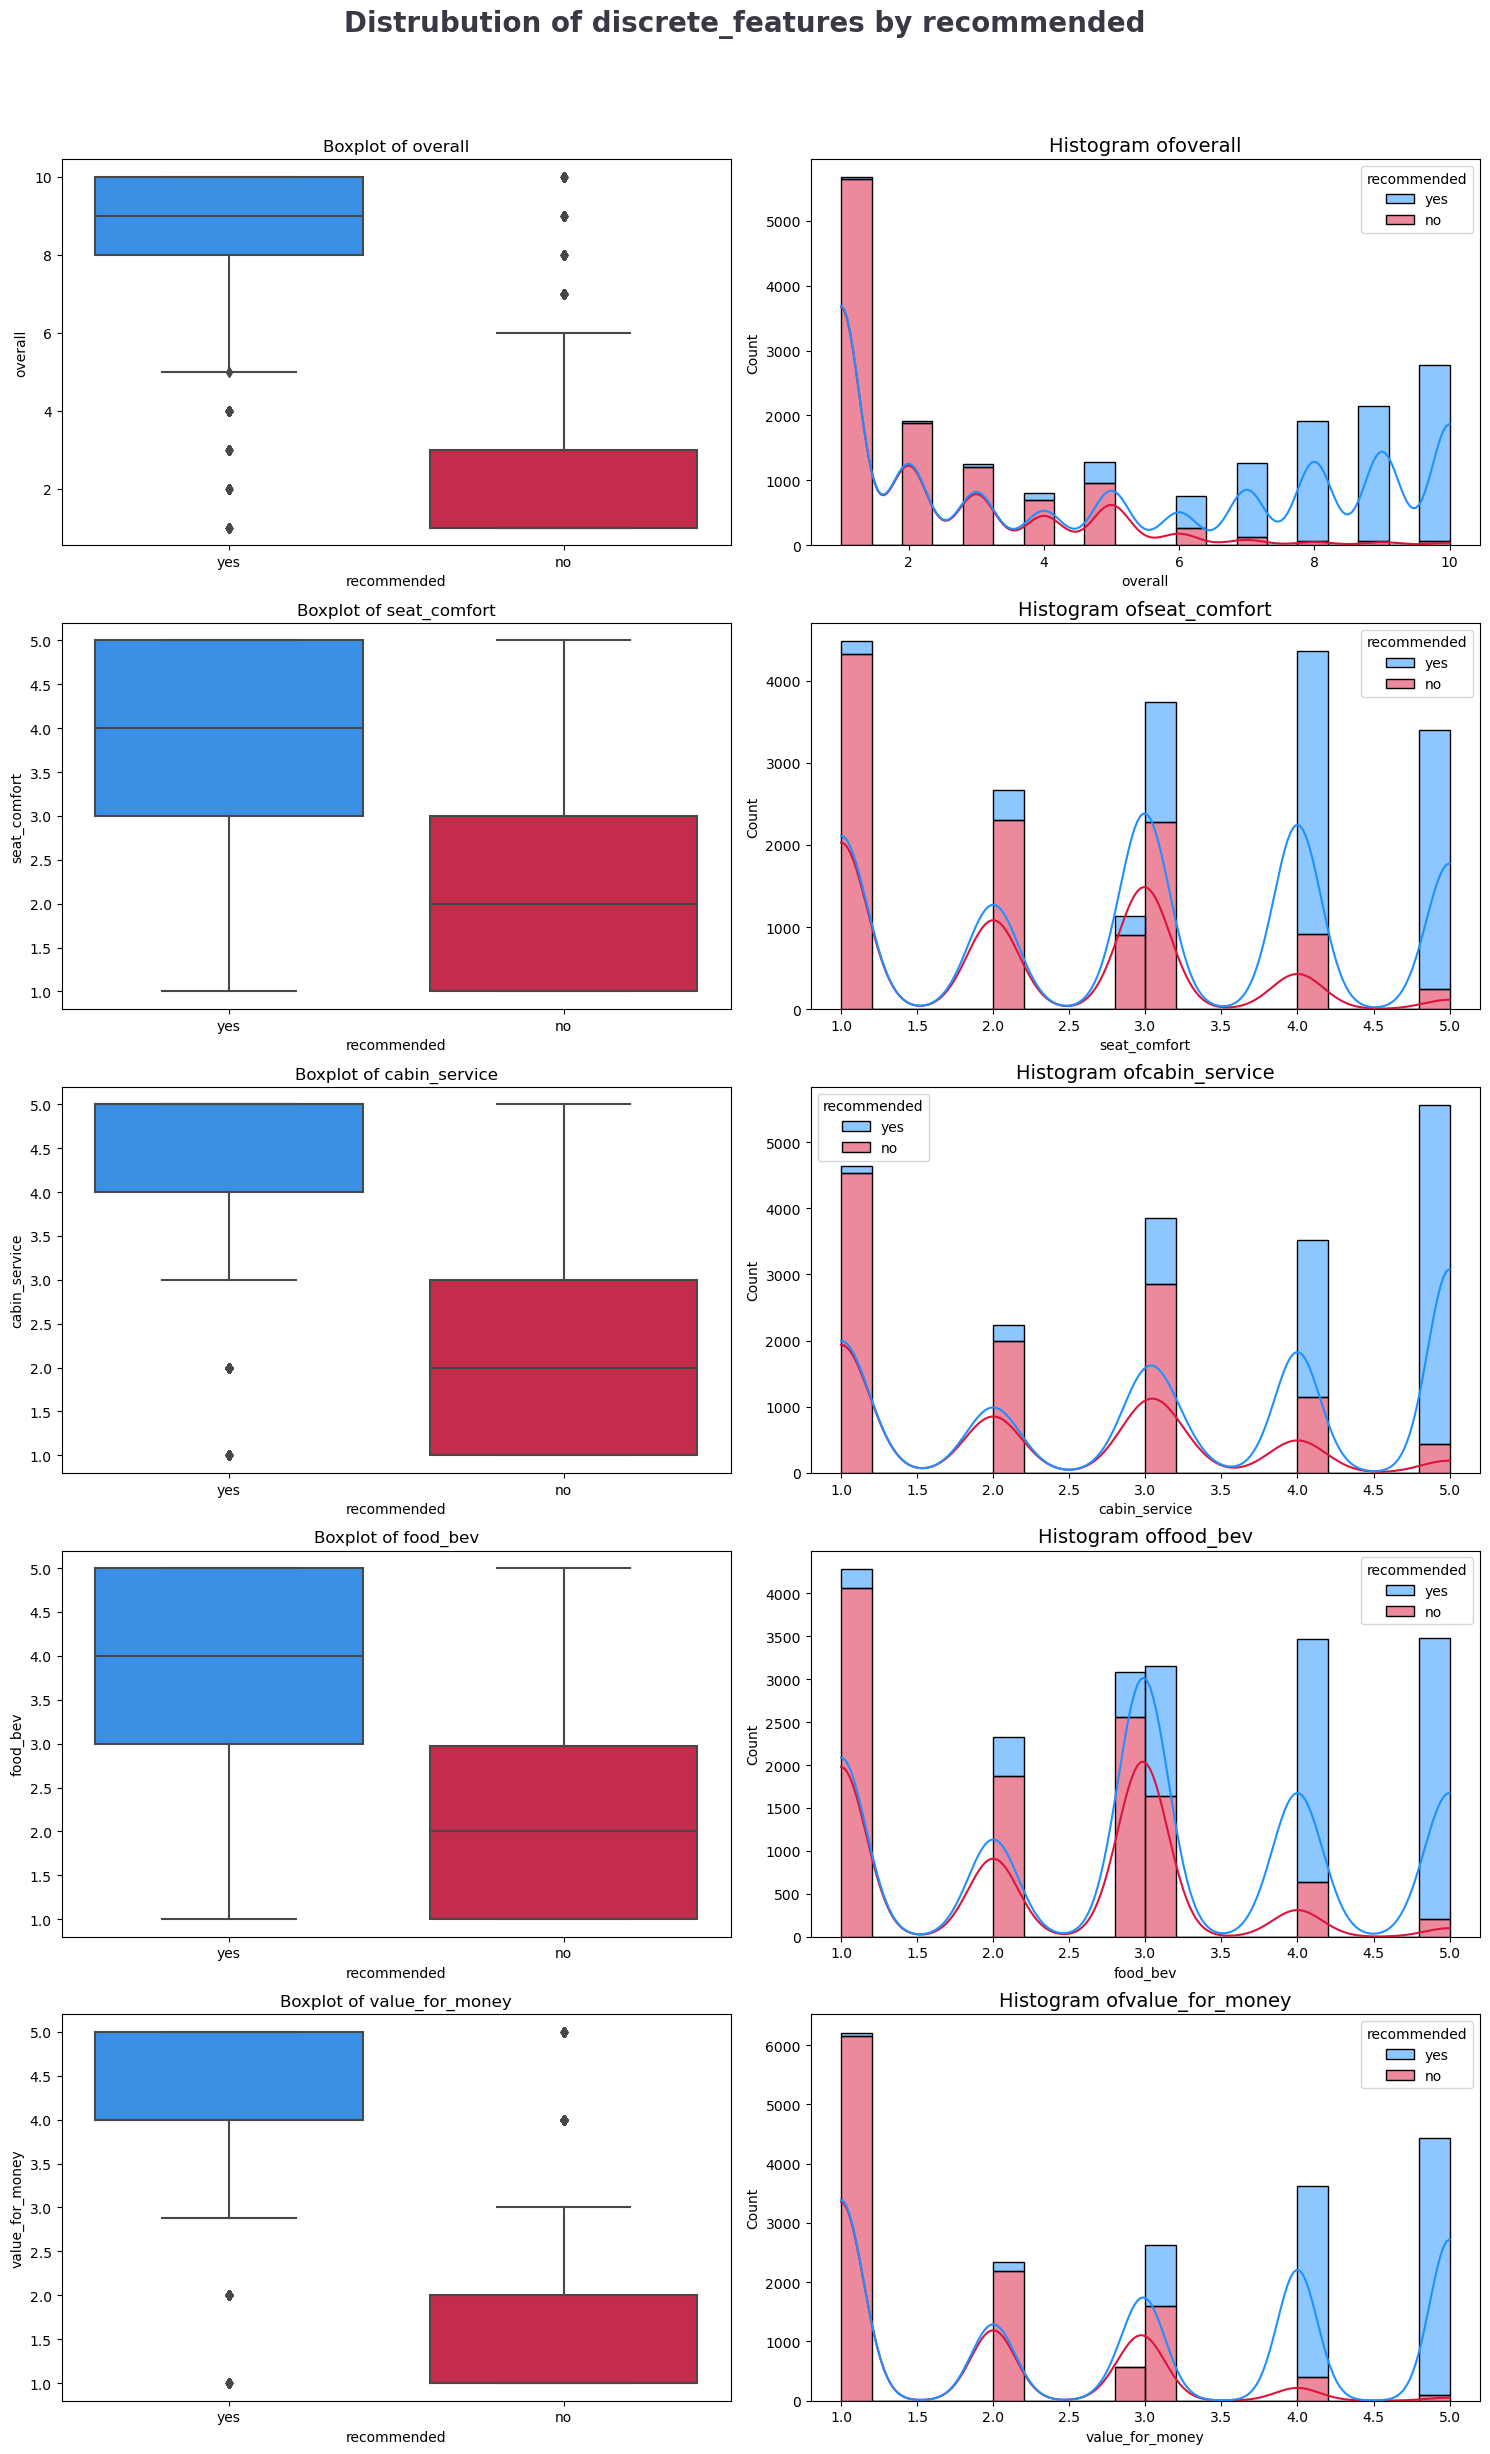

In [47]:
clr1=['#1E90FF','#DC143C']
num_rows=5
nums_cols=math.ceil(len(discrete_features)/num_rows)
fig_width=15
fig_height=5*num_rows
fig,ax=plt.subplots(num_rows,2,figsize=(fig_width,fig_height))
fig.suptitle('Distrubution of discrete_features by recommended',color='#3C3744',fontsize=20,fontweight='bold',ha='center')
for i, col in enumerate(discrete_features):
    if i<num_rows*2:
        row_index=i%num_rows
        col_index=i//num_rows
        sns.boxplot(data=df,x='recommended',y=col,palette=clr1,ax=ax[row_index,0])
        ax[row_index,0].set_title(f'Boxplot of {col}',fontsize=12)
        sns.histplot(data=df,x=col,hue='recommended',bins=20,kde=True,
                    multiple='stack',palette=clr1,ax=ax[row_index,1])
        ax[row_index,1].set_title(f'Histogram of{col}',fontsize=14)
    else:
        break
for i in range(len(discrete_features),num_rows*2):
    ax[i//2,i%2].axis('on')
fig.tight_layout()
fig.subplots_adjust(top=0.92)


In [48]:
continues_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print("num of continous featuress:",continues_features)

num of continous featuress: ['overall', 'sentiment_score']


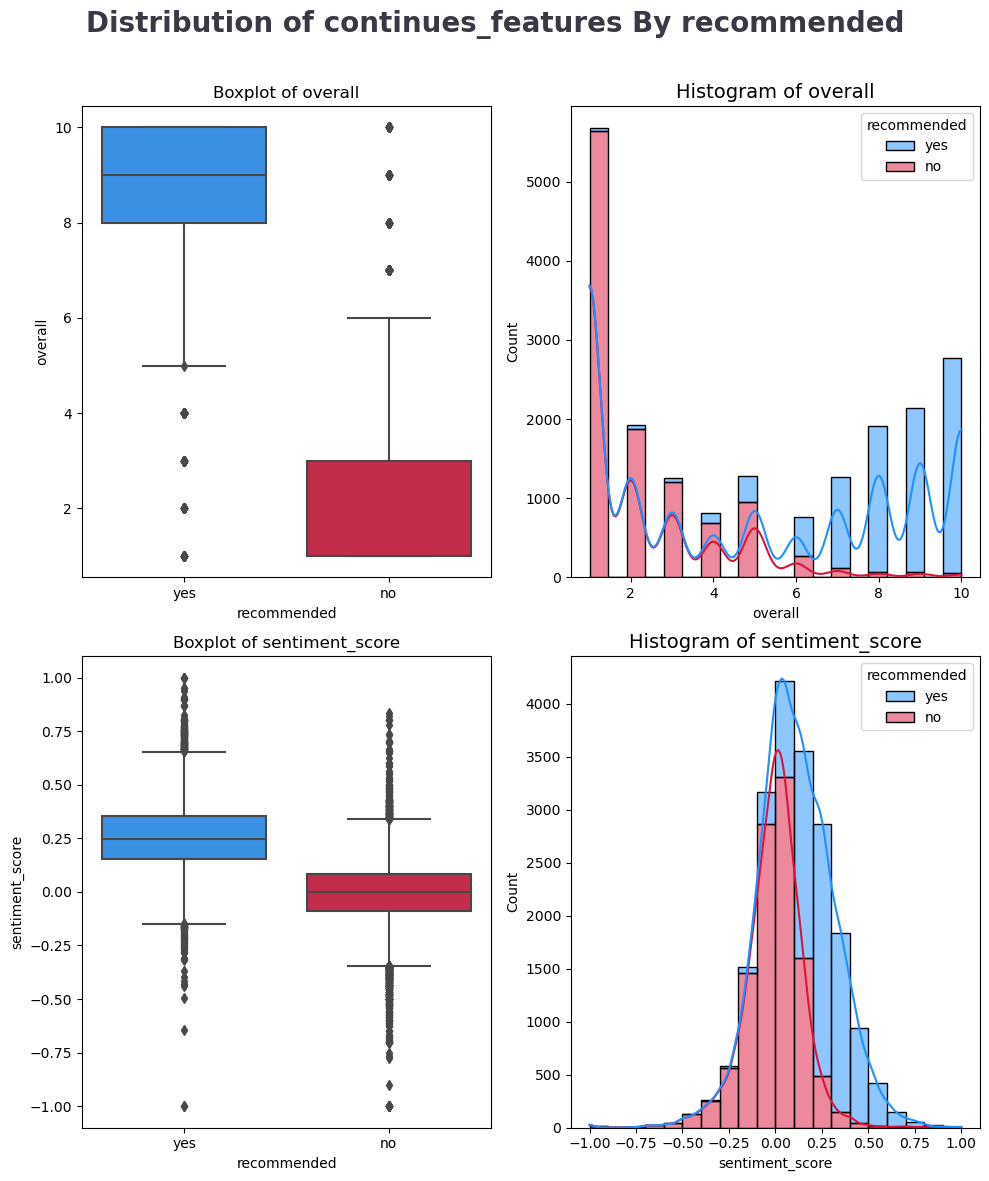

In [49]:
clr1=['#1E90FF','#DC143C']
num_rows=2
fig,ax=plt.subplots(num_rows,2,figsize=(10,12))
fig.suptitle('Distribution of continues_features By recommended',color='#3C3744',fontsize=20,fontweight='bold',ha='center')
for i , col in enumerate((continues_features)):
    sns.boxplot(data=df,x='recommended',y=col,palette=clr1,ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}',fontsize=12)
    sns.histplot(data=df,x=col,hue='recommended',bins=20,kde=True,multiple='stack',palette=clr1,ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)

In [50]:
df.recommended.value_counts()

no     10971
yes     8839
Name: recommended, dtype: int64

In [51]:
df.recommended.value_counts(normalize=True)*100

no     55.381121
yes    44.618879
Name: recommended, dtype: float64

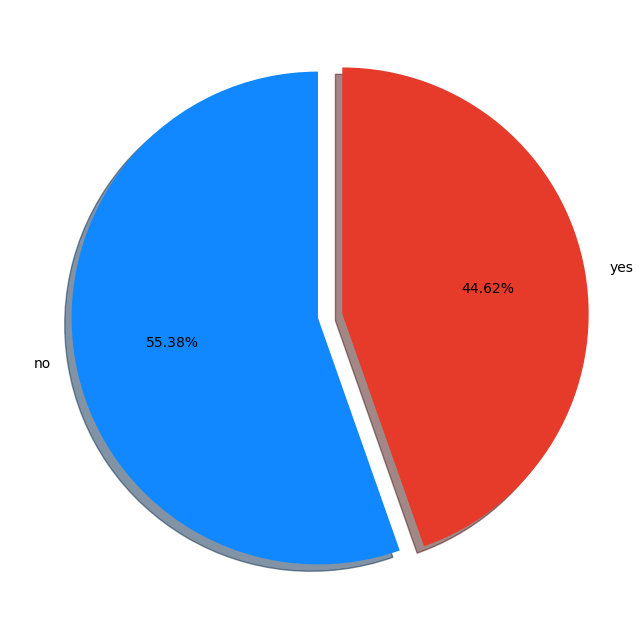

In [52]:
percentage=df.recommended.value_counts(normalize=True)*100
labels=['no','yes']
fig,ax=plt.subplots(figsize=(15,8))
explode=(0,0.1)
colors=['#1188ff','#e63a2a']
ax.pie(percentage, labels=labels,startangle=90,autopct='%1.2f%%',explode=explode,shadow=True,colors=colors)
plt.show()

# 4.2 does airline has any impact on recommended

In [53]:
df.groupby('airline')['recommended'].value_counts(normalize=True).to_frame()*100

recommended
airline                   recommended             
Aegean Airlines           yes            78.679245
                          no             21.320755
Aeroflot Russian Airlines yes            62.674651
                          no             37.325349
Aeromexico                no             60.411899
                          yes            39.588101
Air Canada                no             61.792453
                          yes            38.207547
Air New Zealand           yes            54.440789
                          no             45.559211
Alitalia                  no             60.987654
                          yes            39.012346
American Airlines         no             80.604357
                          yes            19.395643
Delta Air Lines           no             61.042345
                          yes            38.957655
Emirates                  yes            53.545094
                          no             46.454906
Jetblue Airways           no             58.566978
                          yes            41.433022
KLM Royal Dutch Airlines  yes            63.880289
                          no             36.119711
Lufthansa                 yes            70.021413
                          no             29.978587
Qatar Airways             yes            76.993007
                          no             23.006993
Southwest Airlines        no             55.555556
                          yes            44.444444
Turkish Airlines          no             50.879567
                          yes            49.120433
United Airlines           no             79.055516
                          yes            20.944484
Virgin America            yes            60.645161
                          no             39.354839

In [54]:
df2=df.copy()

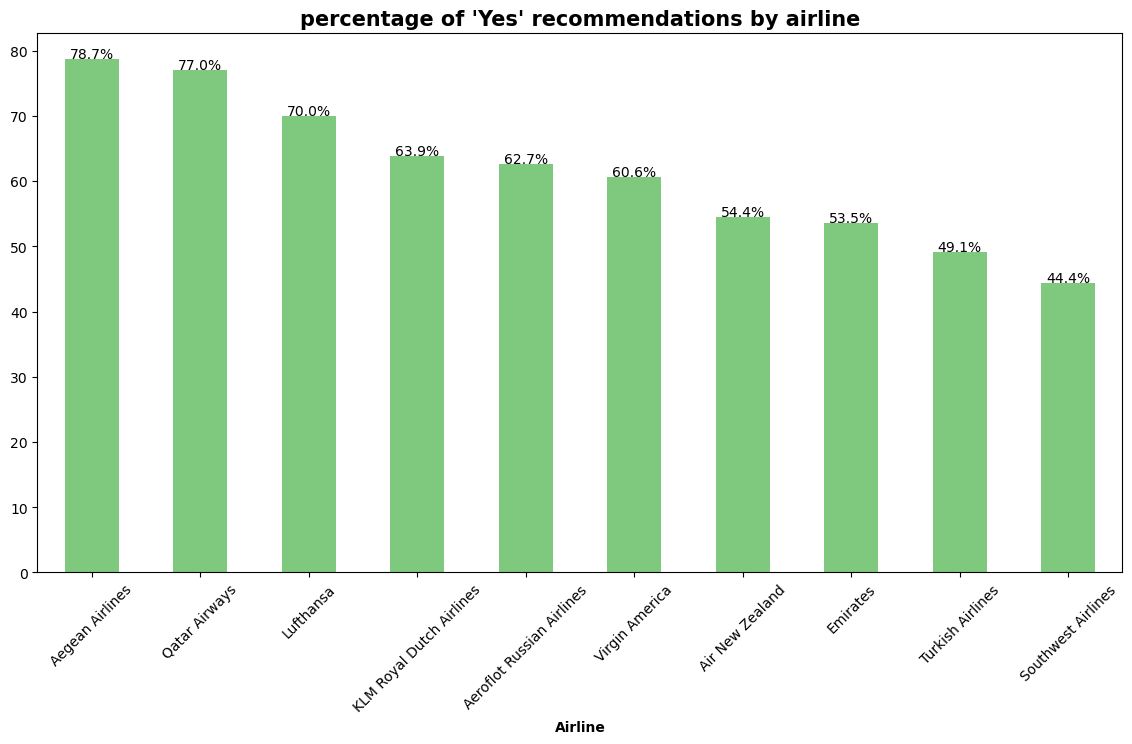

In [55]:
plt.figure(figsize=[14,7])
order1=100*df2[df2['recommended']=='yes']['airline'].value_counts()/df2['airline'].value_counts()
order1_sorted=order1.sort_values(ascending=False).head(10)
order1_sorted.plot(kind='bar',stacked=True,colormap='Accent')
plt.title("percentage of 'Yes' recommendations by airline",fontsize=15,fontweight='bold')
for n in range(order1_sorted.shape[0]):
    count=order1_sorted.iloc[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')
plt.xlabel('Airline',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# the above images tells the airline value high impact on the recommendation variable

# 4.3 does overall have any impact recommended


In [56]:
df.groupby('overall')['recommended'].value_counts(normalize=True).to_frame()*100

recommended
overall   recommended             
1.000000  no             99.471086
          yes             0.528914
2.000000  no             97.864583
          yes             2.135417
3.000000  no             96.181384
          yes             3.818616
4.000000  no             85.326757
          yes            14.673243
4.986561  no             99.681529
          yes             0.318471
5.000000  no             66.459627
          yes            33.540373
6.000000  yes            64.435696
          no             35.564304
7.000000  yes            90.266876
          no              9.733124
8.000000  yes            96.234310
          no              3.765690
9.000000  yes            96.736597
          no              3.263403
10.000000 yes            97.947425
          no              2.052575

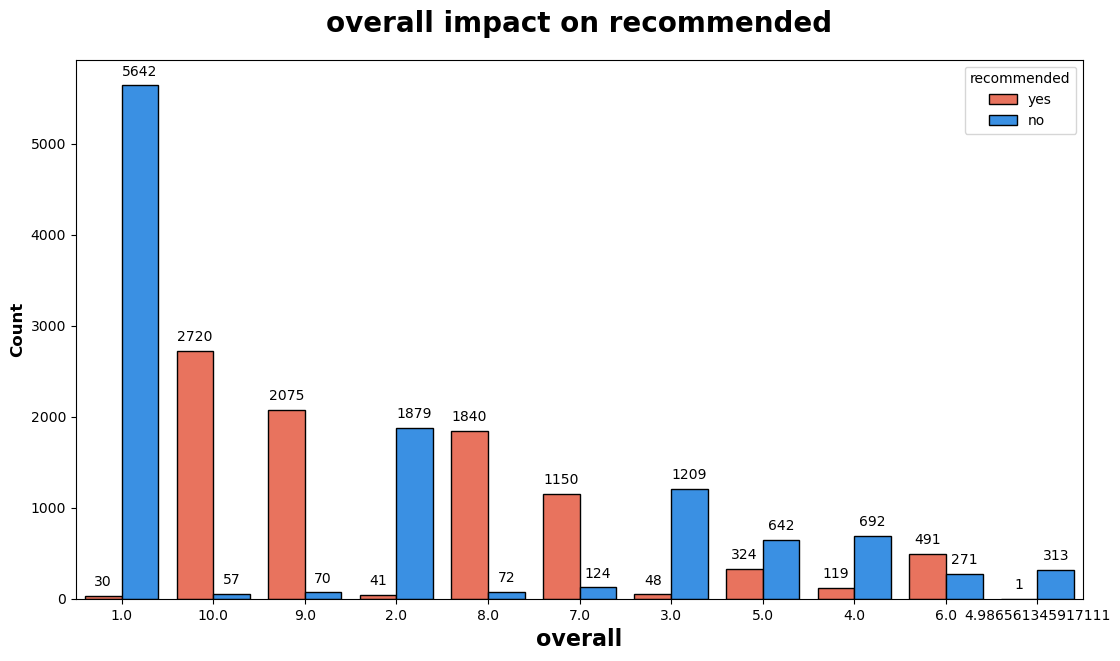

In [57]:
custom_palette=['#FF6347','#1E90FF']
overall_order=df['overall'].value_counts().sort_values(ascending=False).index
plt.subplots(figsize=(13,7))
ax=sns.countplot(x='overall',hue='recommended',data=df,ec="black",palette=custom_palette,order=overall_order)
plt.title("overall impact on recommended",weight="bold",fontsize=20,pad=20)
plt.ylabel("Count",weight="bold",fontsize=12)
plt.xlabel("overall",weight="bold",fontsize=16)
plt.legend(title="recommended",fancybox=True)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')

plt.show()

In [58]:
#overall is highly impact on recommendation neagative

# 4.4 Does cabin has impact on recommended?


In [59]:
df.groupby('cabin')['recommended'].value_counts(normalize=True).to_frame()*100

recommended
cabin           recommended             
Business Class  yes            66.698504
                no             33.301496
Economy Class   no             60.638863
                yes            39.361137
First Class     yes            54.749340
                no             45.250660
Premium Economy no             52.872216
                yes            47.127784

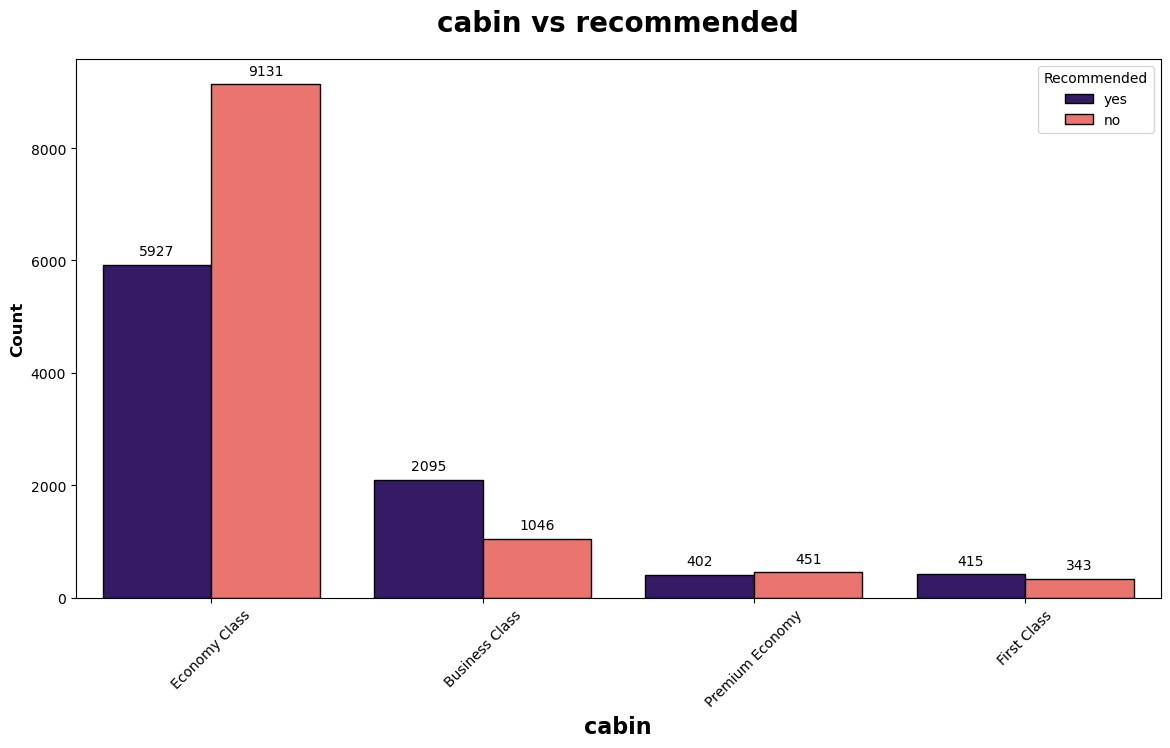

In [60]:
airline_order=df['cabin'].value_counts().index
custom_palette={'yes':'#320D72','no':'#FF6359'}
plt.subplots(figsize=(14,7))
ax=sns.countplot(x='cabin',hue="recommended",data=df,ec="black",palette=custom_palette,order=airline_order)
plt.title("cabin vs recommended",weight="bold",fontsize=20,pad=20)
plt.ylabel("Count",weight="bold",fontsize=12)
plt.xlabel("cabin",weight="bold",fontsize=16)
plt.legend(title="Recommended",fancybox=True)
for p in ax.patches:
    height=p.get_height()
    ax.annotate(format(height,'.0f'), 
                (p.get_x() + p.get_width() / 2.,height), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
plt.xticks(rotation=45)
plt.show()


In [61]:
df.groupby('seat_comfort')['recommended'].value_counts(normalize=True).to_frame()*100

recommended
seat_comfort recommended             
1.000000     no             96.520963
             yes             3.479037
2.000000     no             86.614173
             yes            13.385827
2.975201     no             79.035088
             yes            20.964912
3.000000     no             60.752401
             yes            39.247599
4.000000     yes            79.107551
             no             20.892449
5.000000     yes            92.884446
             no              7.115554

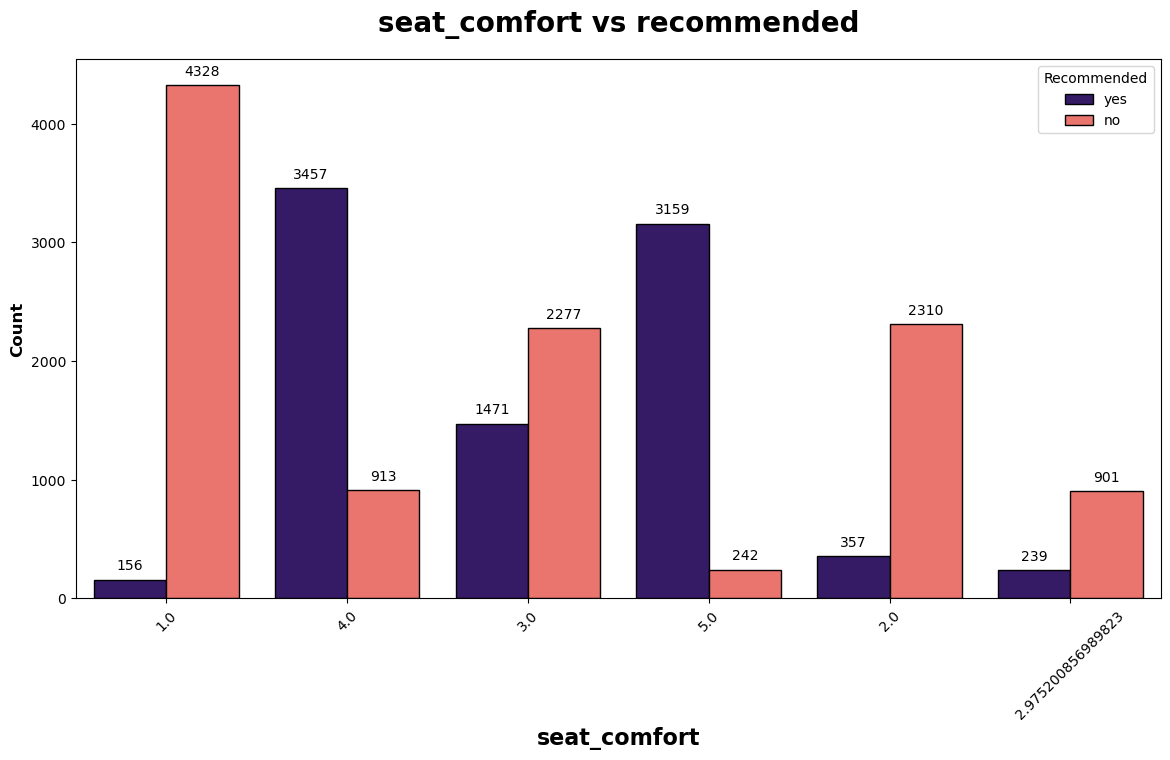

In [62]:
airline_order=df['seat_comfort'].value_counts().index
custom_palette={'yes':'#320D72','no':'#FF6359'}
plt.subplots(figsize=(14,7))
ax=sns.countplot(x='seat_comfort',hue="recommended",data=df,ec="black",palette=custom_palette,order=airline_order)
plt.title("seat_comfort vs recommended",weight="bold",fontsize=20,pad=20)
plt.ylabel("Count",weight="bold",fontsize=12)
plt.xlabel("seat_comfort",weight="bold",fontsize=16)
plt.legend(title="Recommended",fancybox=True)
for p in ax.patches:
    height=p.get_height()
    ax.annotate(format(height,'.0f'), 
                (p.get_x() + p.get_width() / 2.,height), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
plt.xticks(rotation=45)
plt.show()


# 4.6 Does cabin_service has impact on recommended?

In [63]:
 df.groupby('cabin_service')['recommended'].value_counts(normalize=True).to_frame()*100

recommended
cabin_service recommended             
1.000000      no             97.737557
              yes             2.262443
2.000000      no             89.107143
              yes            10.892857
3.000000      no             72.150971
              yes            27.849029
3.166738      no             79.055258
              yes            20.944742
4.000000      yes            67.339397
              no             32.660603
5.000000      yes            92.194245
              no              7.805755

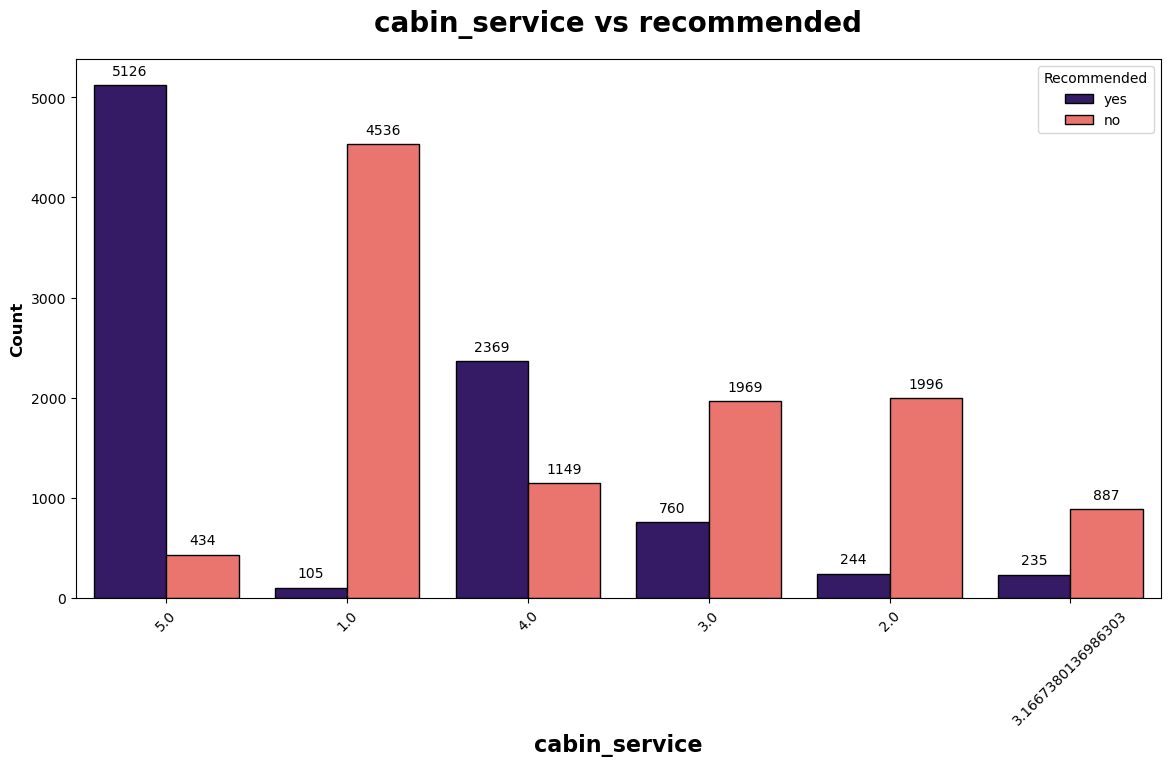

In [64]:
airline_order=df['cabin_service'].value_counts().index
custom_palette={'yes':'#320D72','no':'#FF6359'}
plt.subplots(figsize=(14,7))
ax=sns.countplot(x='cabin_service',hue="recommended",data=df,ec="black",palette=custom_palette,order=airline_order)
plt.title("cabin_service vs recommended",weight="bold",fontsize=20,pad=20)
plt.ylabel("Count",weight="bold",fontsize=12)
plt.xlabel("cabin_service",weight="bold",fontsize=16)
plt.legend(title="Recommended",fancybox=True)
for p in ax.patches:
    height=p.get_height()
    ax.annotate(format(height,'.0f'), 
                (p.get_x() + p.get_width() / 2.,height), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
plt.xticks(rotation=45)
plt.show()


# 4.7 does food bev has impact on recommended

In [65]:
 df.groupby('food_bev')['recommended'].value_counts(normalize=True).to_frame()*100

recommended
food_bev recommended             
1.000000 no             94.749125
         yes             5.250875
2.000000 no             80.102916
         yes            19.897084
2.972088 no             83.143878
         yes            16.856122
3.000000 no             51.962025
         yes            48.037975
4.000000 yes            81.658508
         no             18.341492
5.000000 yes            94.139615
         no              5.860385

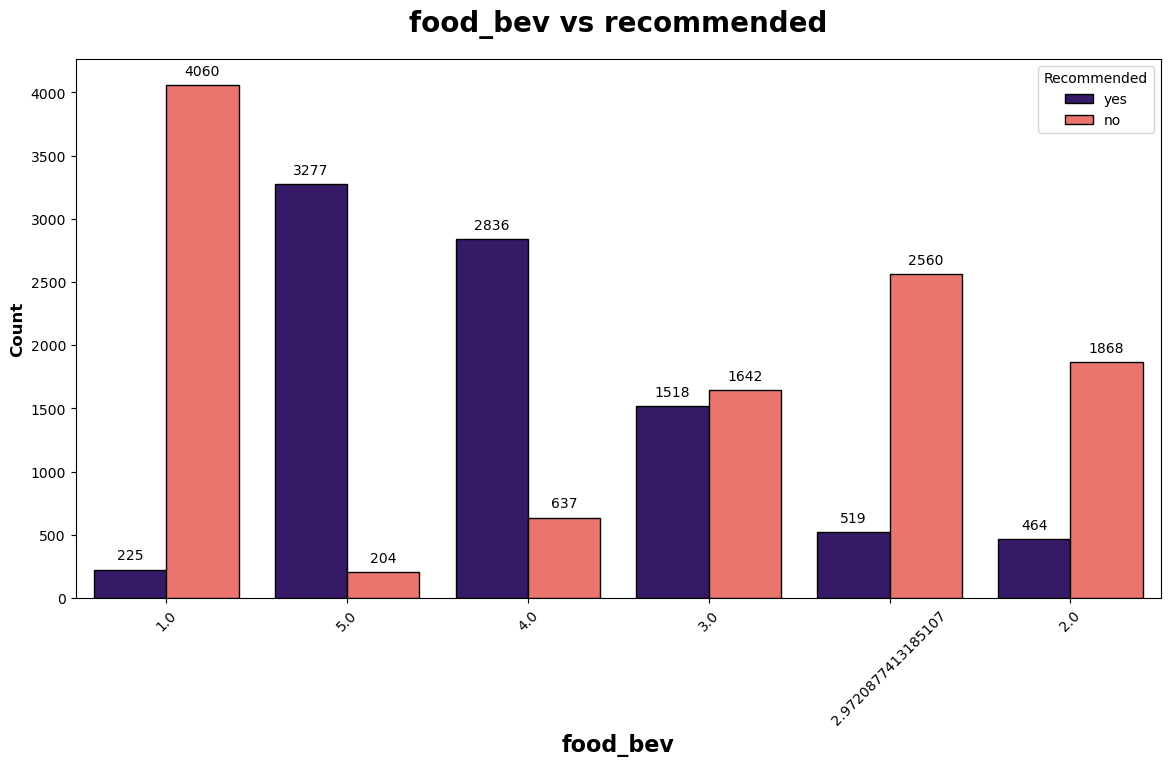

In [66]:
airline_order=df['food_bev'].value_counts().index
custom_palette={'yes':'#320D74','no':'#FF6359'}
plt.subplots(figsize=(14,7))
ax=sns.countplot(x='food_bev',hue="recommended",data=df,ec="black",palette=custom_palette,order=airline_order)
plt.title("food_bev vs recommended",weight="bold",fontsize=20,pad=20)
plt.ylabel("Count",weight="bold",fontsize=12)
plt.xlabel("food_bev",weight="bold",fontsize=16)
plt.legend(title="Recommended",fancybox=True)
for p in ax.patches:
    height=p.get_height()
    ax.annotate(format(height,'.0f'), 
                (p.get_x() + p.get_width() / 2.,height), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
plt.xticks(rotation=45)
plt.show()


# 4.8 does value_for_money  has impact on recommended

In [67]:
 df.groupby('value_for_money')['recommended'].value_counts(normalize=True).to_frame()*100

recommended
value_for_money recommended             
1.000000        no             99.146538
                yes             0.853462
2.000000        no             93.122597
                yes             6.877403
2.881561        no             99.119718
                yes             0.880282
3.000000        no             60.341556
                yes            39.658444
4.000000        yes            89.201102
                no             10.798898
5.000000        yes            97.989155
                no              2.010845

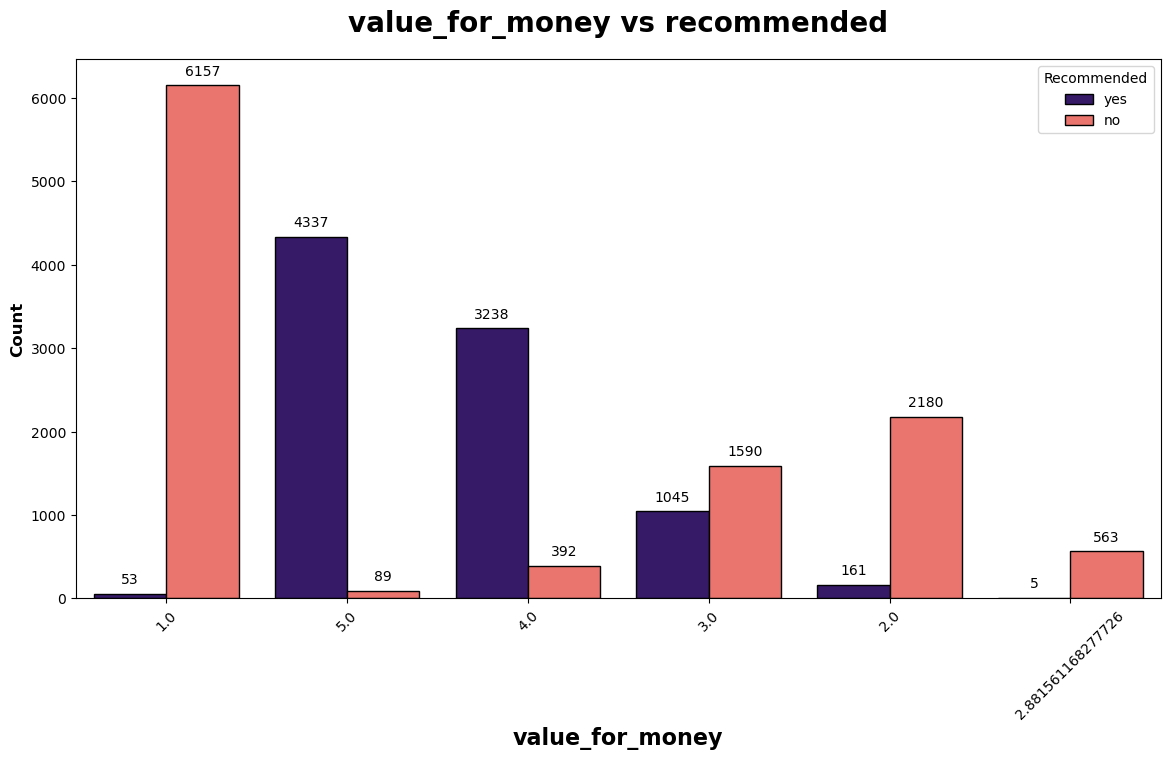

In [68]:
airline_order=df['value_for_money'].value_counts().index
custom_palette={'yes':'#320D74','no':'#FF6359'}
plt.subplots(figsize=(14,7))
ax=sns.countplot(x='value_for_money',hue="recommended",data=df,ec="black",palette=custom_palette,order=airline_order)
plt.title("value_for_money vs recommended",weight="bold",fontsize=20,pad=20)
plt.ylabel("Count",weight="bold",fontsize=12)
plt.xlabel("value_for_money",weight="bold",fontsize=16)
plt.legend(title="Recommended",fancybox=True)
for p in ax.patches:
    height=p.get_height()
    ax.annotate(format(height,'.0f'), 
                (p.get_x() + p.get_width() / 2.,height), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
plt.xticks(rotation=45)
plt.show()


In [69]:
 df.groupby(['sentiment_score'])['recommended'].value_counts(normalize=True).to_frame()*100

recommended
sentiment_score recommended             
-1.000000       no                  87.5
                yes                 12.5
-0.900000       no                 100.0
-0.775000       no                 100.0
-0.766667       no                 100.0
...                                  ...
 0.910000       yes                100.0
 0.938333       yes                100.0
 0.950000       yes                100.0
 0.953333       yes                100.0
 1.000000       yes                100.0

[16599 rows x 1 columns]

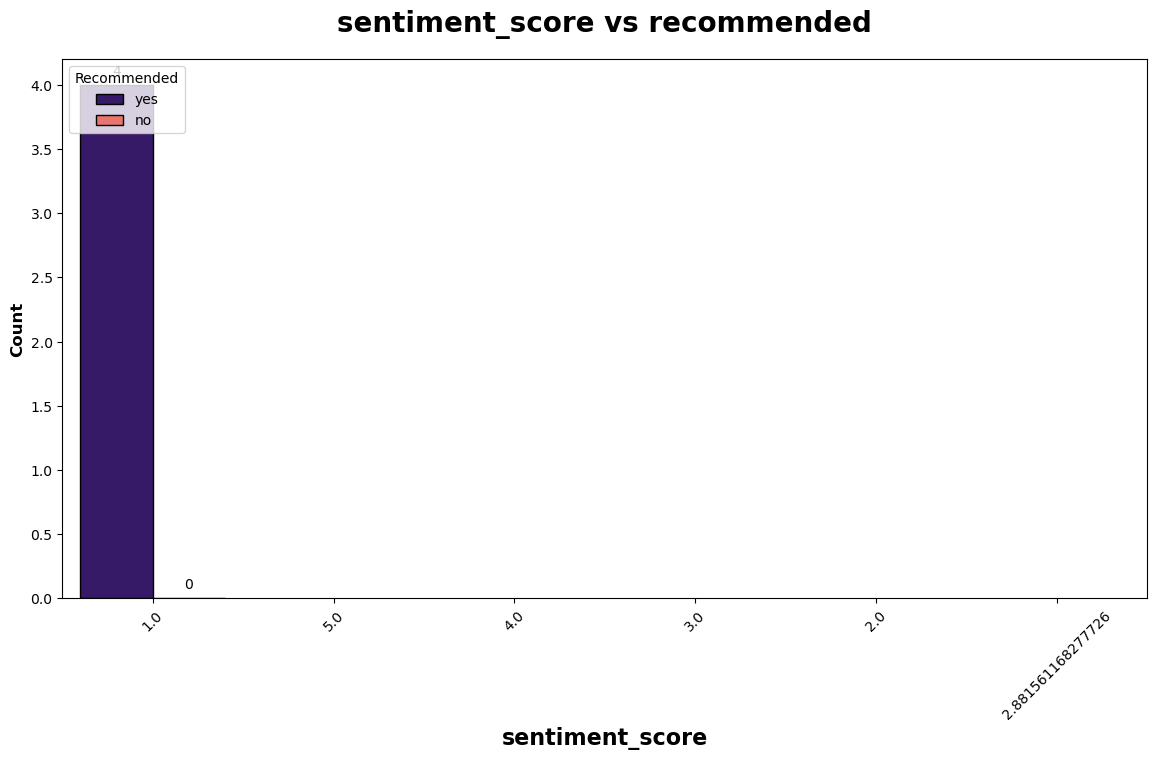

In [70]:
sentiment_score=df['sentiment_score'].value_counts().index
custom_palette={'yes':'#320D74','no':'#FF6359'}
plt.subplots(figsize=(14,7))
ax=sns.countplot(x='sentiment_score',hue="recommended",data=df,ec="black",palette=custom_palette,order=airline_order)
plt.title("sentiment_score vs recommended",weight="bold",fontsize=20,pad=20)
plt.ylabel("Count",weight="bold",fontsize=12)
plt.xlabel("sentiment_score",weight="bold",fontsize=16)
plt.legend(title="Recommended",fancybox=True)
for p in ax.patches:
    height=p.get_height()
    ax.annotate(format(height,'.0f'), 
                (p.get_x() + p.get_width() / 2.,height), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
plt.xticks(rotation=45)
plt.show()


In [71]:
num_df=df.select_dtypes(exclude=['object'])
num_df.corr()

,overall,seat_comfort,cabin_service,food_bev,value_for_money,sentiment_score
overall,1.000000,0.746669,0.759657,0.701324,0.878016,0.687183
seat_comfort,0.746669,1.000000,0.678304,0.646041,0.734455,0.568602
cabin_service,0.759657,0.678304,1.000000,0.688656,0.723935,0.568770
food_bev,0.701324,0.646041,0.688656,1.000000,0.679965,0.550266
value_for_money,0.878016,0.734455,0.723935,0.679965,1.000000,0.626529
sentiment_score,0.687183,0.568602,0.568770,0.550266,0.626529,1.000000


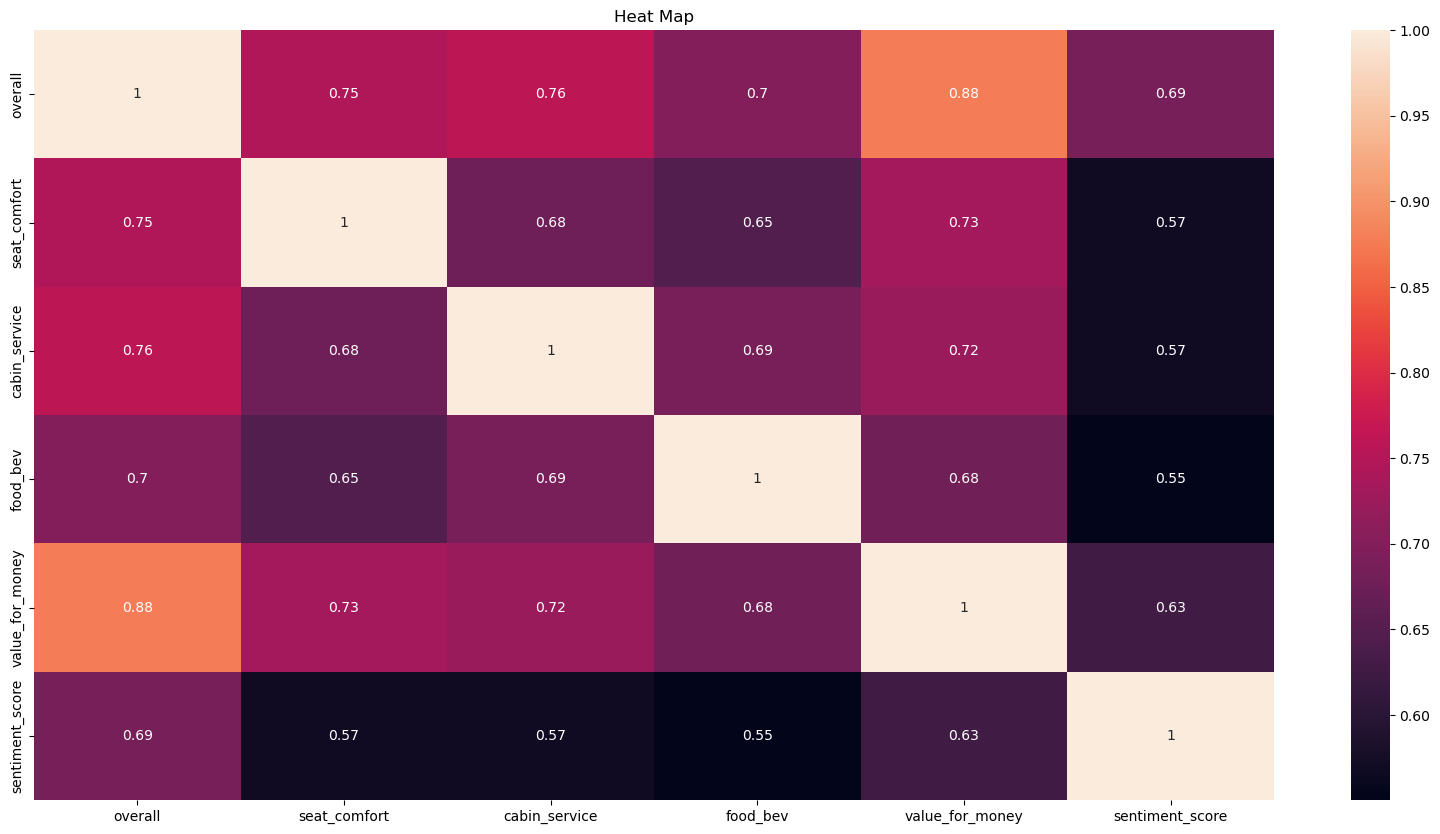

In [72]:
plt.figure(figsize=(20,10))
corelation=num_df.corr()
sns.heatmap(corelation,annot=True)
plt.title("Heat Map")
plt.show()

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):
    vif=pd.DataFrame()
    vif['variables']=X.columns
    vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
    return (vif)

In [74]:
calc_vif(df[[i for i in df.describe().columns if i not in["recommended"]]])

,variables,VIF
0,overall,16.589861
1,seat_comfort,13.042948
2,cabin_service,13.832334
3,food_bev,12.002446
4,value_for_money,20.117116
5,sentiment_score,2.230386


In [75]:
calc_vif(df[[i for i in df.describe().columns if i not in["recommended","value_for_money"]]])

,variables,VIF
0,overall,11.201161
1,seat_comfort,12.045022
2,cabin_service,13.491022
3,food_bev,11.601385
4,sentiment_score,2.224392


In [76]:
calc_vif(df[[i for i in df.describe().columns if i not in["recommended","value_for_money"]]])

,variables,VIF
0,overall,11.201161
1,seat_comfort,12.045022
2,cabin_service,13.491022
3,food_bev,11.601385
4,sentiment_score,2.224392


In [77]:
calc_vif(df[[i for i in df.describe().columns if i not in["recommended","value_for_money","cabin_service"]]])

,variables,VIF
0,overall,10.050238
1,seat_comfort,10.758955
2,food_bev,9.418750
3,sentiment_score,2.217111


In [78]:
calc_vif(df[[i for i in df.describe().columns if i not in["recommended","value_for_money","cabin_service","seat_comfort"]]])

,variables,VIF
0,overall,7.941581
1,food_bev,6.094644
2,sentiment_score,2.203340


In [79]:
calc_vif(df[[i for i in df.describe().columns if i not in["recommended","value_for_money","cabin_service","seat_comfort","overall"]]])

,variables,VIF
0,food_bev,1.658065
1,sentiment_score,1.658065


In [80]:
df.drop(columns=['value_for_money','cabin_service','seat_comfort','overall'],inplace=True)

In [81]:
df.columns

Index(['airline', 'cabin', 'food_bev', 'recommended', 'sentiment_score'], dtype='object')

In [82]:
df.head(2)

,airline,cabin,food_bev,recommended,sentiment_score
1,Turkish Airlines,Economy Class,4.0,yes,0.260263
3,Turkish Airlines,Economy Class,1.0,no,0.116667


In [83]:
x=df.drop("recommended",axis=1)
y=df['recommended']

In [84]:
y.head()

1    yes
3     no
5     no
7    yes
9     no
Name: recommended, dtype: object

In [85]:
y=np.where(y=='yes',2,0)

In [86]:
y

array([2, 0, 0, ..., 2, 0, 0])

# feature Transformation

In [87]:
num_features=[feature for feature in df.columns if df[feature].dtype !='O']
continuos_features=[feature for feature in num_features if len(df[feature].unique())>25]
print('we have{}continuos_features:{}'.format(len(continous_features),continous_features))


we have1continuos_features:['sentiment_score']


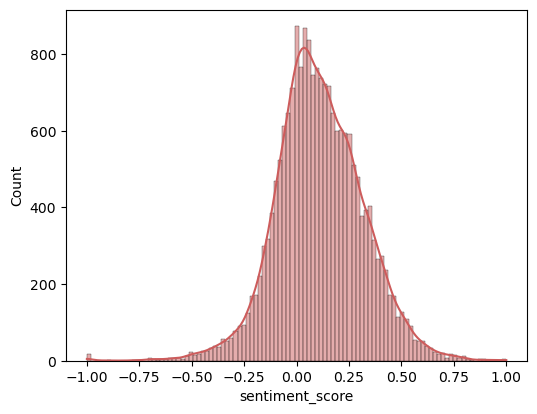

In [88]:
plt.figure(figsize=(15,12))
for i, col in enumerate(['sentiment_score']):
    plt.subplot(3,3,i+1)
    sns.histplot(x=x[col],color='indianred',kde=True)
    plt.xlabel(col)
    plt.tight_layout()

In [89]:
#check sknewness
x[continuos_features].skew(axis=0,skipna=True)

sentiment_score   -0.034101
dtype: float64

# Apply power Transformer to check if it can reduces the outliers

In [90]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
transform_features=['sentiment_score']
x_copy=pt.fit_transform(x[transform_features])

In [91]:
x_copy=pd.DataFrame(x_copy,columns=transform_features)


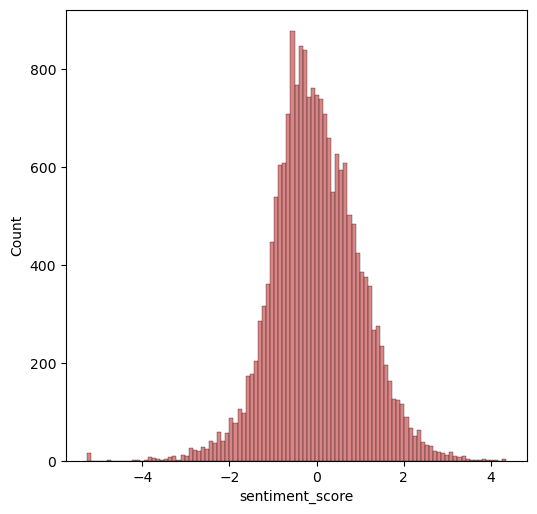

In [92]:
plt.figure(figsize=(15,15))
for i,col in enumerate(transform_features):
    plt.subplot(3,3,i+1)
    sns.histplot(x=x_copy[col],color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [93]:
x_copy

,sentiment_score
0,0.722797
1,0.026921
2,-0.440422
3,1.136164
4,0.389940
...,...
19805,0.365709
19806,0.969327
19807,1.796248
19808,-0.595717


# Preprocessing using Column Transformer

In [94]:
or_columns=['airline','cabin']
transform_columns=['sentiment_score']
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
numeric_transformer=StandardScaler()
ordinal_encoder=OrdinalEncoder()
transform_pipe=Pipeline(steps=[
    ('transformer',PowerTransformer(method='yeo-johnson'))
                              ])
preprocessor=ColumnTransformer([
    ("Ordinal_Encoder",ordinal_encoder,or_columns),
    ("transformer",transform_pipe,transform_columns),
    ("StandardScaler",numeric_transformer,num_features)
])

In [95]:
x=preprocessor.fit_transform(x)

In [96]:
x

array([[14.        ,  1.        ,  0.72279713,  0.75360607,  0.72426126],
       [14.        ,  1.        ,  0.02692101, -1.44582117,  0.03063059],
       [14.        ,  1.        , -0.44042203, -1.44582117, -0.43726037],
       ...,
       [ 5.        ,  1.        ,  1.79624763,  0.02046366,  1.78797931],
       [ 5.        ,  1.        , -0.59571734, -1.44582117, -0.59313748],
       [ 5.        ,  1.        , -1.33008999, -0.71267875, -1.33295356]])

In [97]:
x.shape

(19810, 5)

# classification

In [98]:
y.shape

(19810,)

In [99]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((15848, 5), (3962, 5))

In [102]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score,roc_curve
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

ModuleNotFoundError: No module named 'xgboost'